In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import roc_auc_score

INTEGRATED_PATH = "../data/integrated/algeria_wildfire_dataset.parquet"
OUT_DIR = Path("outputs/validation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RISK_LABELS = {0: "NO_FIRE", 1: "ACTIVE", 2: "SIGNIFICANT"}
COLORS = {0: "#2d6a4f", 1: "#f4a261", 2: "#c1121f"}
palette = [COLORS[i] for i in range(3)]

### Overview

In [3]:
df = pd.read_parquet(INTEGRATED_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape:       {df.shape}")
print(f"Date range:  {df['date'].min()} → {df['date'].max()}")
print(f"Wilayas:     {df['wilaya_id'].nunique()}")
print(f"Columns:     {list(df.columns)}")

DATASET OVERVIEW
Shape:       (95664, 32)
Date range:  2015-06-01 00:00:00 → 2025-10-31 00:00:00
Wilayas:     48
Columns:     ['date', 'wilaya_id', 'wilaya_name', 'year', 'month', 'day_of_year', 'temp_c', 'rh', 'wind_speed_kmh', 'wind_dir', 'precip_mm', 'soil_moisture', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'NDVI', 'NDWI', 'NBR', 'elevation_mean_m', 'slope_mean_deg', 'aspect_mean_deg', 'pop_density_mean', 'road_distance_mean_km', 'era5_cell_id', 'fire_count', 'frp_sum', 'frp_max', 'fire_risk_class', 'fire_risk_label']


### Missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✓ No missing values")
else:
    print(missing.sort_values(ascending=False))

✓ No missing values


### Duplicates and Infinite Values 

In [5]:
dups = df.duplicated(["date", "wilaya_id"]).sum()
print(f"{'✓' if dups == 0 else '⚠'} (date, wilaya_id) duplicates: {dups}")

numeric = df.select_dtypes(include=np.number)
inf_count = np.isinf(numeric.to_numpy()).sum()
print(f"{'✓' if inf_count == 0 else '⚠'} Infinite values: {inf_count}")

✓ (date, wilaya_id) duplicates: 0
✓ Infinite values: 0


### Class Distribution

  0 NO_FIRE       62,289 ( 65.1%)  ██████████████████████████
  1 ACTIVE        23,757 ( 24.8%)  █████████
  2 SIGNIFICANT    9,618 ( 10.1%)  ████


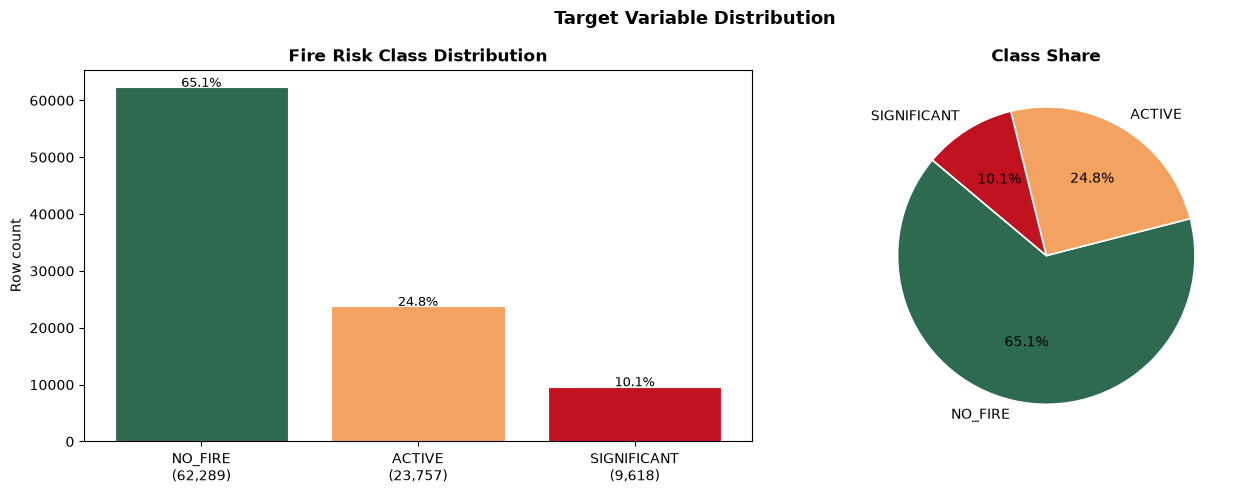

In [6]:
dist = df["fire_risk_class"].value_counts().sort_index()
for cls, count in dist.items():
    bar = "█" * int(40 * count / len(df))
    print(f"  {cls} {RISK_LABELS[cls]:<12} {count:>7,} ({100*count/len(df):5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"{RISK_LABELS[i]}\n({dist[i]:,})" for i in dist.index]
axes[0].bar(labels, dist.values, color=palette, edgecolor="white", linewidth=0.8)
axes[0].set_title("Fire Risk Class Distribution", fontweight="bold")
axes[0].set_ylabel("Row count")
for bar, val in zip(axes[0].patches, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f"{100*val/len(df):.1f}%", ha="center", fontsize=9)

axes[1].pie(dist.values, labels=[RISK_LABELS[i] for i in dist.index],
            colors=palette, autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.2})
axes[1].set_title("Class Share", fontweight="bold")

plt.suptitle("Target Variable Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_class_distribution.png", dpi=150)
plt.show()

In [7]:
checks = {
    "temp_c":             (-10, 55),
    "rh":                 (0, 100),
    "wind_speed_kmh":     (0, 150),
    "precip_mm":          (0, 300),
    "FFMC":               (0, 101),
    "FWI":                (0, 350),
    "NDVI":               (-1, 1),
    "soil_moisture":      (0, 1),
    "elevation_mean_m":   (0, 3000),
    "slope_mean_deg":     (0, 90),
}
for col, (lo, hi) in checks.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    bad = ((s < lo) | (s > hi)).sum()
    print(f"  {'✓' if bad == 0 else '⚠'} {col:<22} "
          f"min={s.min():8.2f}  max={s.max():8.2f}  out_of_range={bad}")

  ✓ temp_c                 min=    4.99  max=   48.21  out_of_range=0
  ✓ rh                     min=    2.46  max=  100.00  out_of_range=0
  ✓ wind_speed_kmh         min=    0.04  max=   58.21  out_of_range=0
  ✓ precip_mm              min=    0.00  max=   58.14  out_of_range=0
  ✓ FFMC                   min=    3.55  max=  100.94  out_of_range=0
  ✓ FWI                    min=    0.00  max=  260.56  out_of_range=0
  ✓ NDVI                   min=   -0.08  max=    0.72  out_of_range=0
  ⚠ soil_moisture          min=   -0.02  max=    0.46  out_of_range=864
  ✓ elevation_mean_m       min=   75.48  max= 1154.74  out_of_range=0
  ✓ slope_mean_deg         min=    0.21  max=    5.95  out_of_range=0


### Feature Completeness

In [8]:
feature_groups = {
    "Weather (ERA5)":  ["temp_c", "rh", "wind_speed_kmh", "precip_mm", "soil_moisture"],
    "FWI":             ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"],
    "Vegetation":      ["NDVI", "NDWI", "NBR"],
    "Terrain":         ["elevation_mean_m", "slope_mean_deg", "aspect_mean_deg"],
    "Human exposure":  ["pop_density_mean", "road_distance_mean_km"],
}
for group, cols in feature_groups.items():
    present   = [c for c in cols if c in df.columns]
    missing_g = [c for c in cols if c not in df.columns]
    pct_null  = df[present].isnull().mean().mean() * 100 if present else 100
    status    = "✓" if not missing_g and pct_null < 1 else "⚠"
    print(f"  {status} {group:<20} present={len(present)}/{len(cols)}  null={pct_null:.1f}%"
          + (f"  MISSING: {missing_g}" if missing_g else ""))

  ✓ Weather (ERA5)       present=5/5  null=0.0%
  ✓ FWI                  present=6/6  null=0.0%
  ✓ Vegetation           present=3/3  null=0.0%
  ✓ Terrain              present=3/3  null=0.0%
  ✓ Human exposure       present=2/2  null=0.0%


### FWI Check 

In [9]:
has_fire = (df["fire_risk_class"] > 0)
print(f"  Mean FWI — fire days    : {df.loc[has_fire,  'FWI'].mean():.2f}")
print(f"  Mean FWI — no-fire days : {df.loc[~has_fire, 'FWI'].mean():.2f}")

auc = roc_auc_score(has_fire.astype(int), df["FWI"])
print(f"  Binary AUC (FWI)        : {auc:.3f} {'✓' if auc > 0.5 else '⚠'}")

# Per-year AUC
print("\n  AUC per year:")
for year, grp in df.groupby("year"):
    y = (grp["fire_risk_class"] > 0).astype(int)
    if y.sum() > 0 and y.sum() < len(y):
        yr_auc = roc_auc_score(y, grp["FWI"])
        print(f"    {year}: {yr_auc:.3f} {'✓' if yr_auc > 0.5 else '⚠'}")

  Mean FWI — fire days    : 44.78
  Mean FWI — no-fire days : 36.44
  Binary AUC (FWI)        : 0.600 ✓

  AUC per year:
    2015: 0.648 ✓
    2016: 0.604 ✓
    2017: 0.612 ✓
    2018: 0.670 ✓
    2019: 0.616 ✓
    2020: 0.553 ✓
    2021: 0.594 ✓
    2022: 0.566 ✓
    2023: 0.656 ✓
    2024: 0.593 ✓
    2025: 0.571 ✓


### Temporal Coverage

In [10]:
yearly = df.groupby("year").agg(
    rows=("date", "count"),
    fire_rows=("fire_risk_class", lambda x: (x > 0).sum()),
    wilayas=("wilaya_id", "nunique"),
    fire_pct=("fire_risk_class", lambda x: f"{100*(x>0).mean():.1f}%")
)
print(yearly.to_string())

      rows  fire_rows  wilayas fire_pct
year                                   
2015  7344       2086       48    28.4%
2016  8832       2570       48    29.1%
2017  8832       2694       48    30.5%
2018  8832       2536       48    28.7%
2019  8832       3385       48    38.3%
2020  8832       3528       48    39.9%
2021  8832       2492       48    28.2%
2022  8832       2627       48    29.7%
2023  8832       2477       48    28.0%
2024  8832       4239       48    48.0%
2025  8832       4741       48    53.7%


### Summary Statistics

In [11]:
cols = ["temp_c", "rh", "precip_mm", "soil_moisture",
        "FWI", "DMC", "DC", "NDVI", "NBR",
        "elevation_mean_m", "pop_density_mean"]
cols = [c for c in cols if c in df.columns]
print(df[cols].describe().round(2).to_string())

         temp_c        rh  precip_mm  soil_moisture       FWI       DMC        DC      NDVI       NBR  elevation_mean_m  pop_density_mean
count  95664.00  95664.00   95664.00       95664.00  95664.00  95664.00  95664.00  95664.00  95664.00          95664.00          95664.00
mean      30.03     35.02       0.62           0.11     39.35    229.73    653.54      0.21      0.02            585.85            304.36
std        6.13     17.57       2.35           0.09     26.55    259.13    395.21      0.14      0.12            291.45            776.69
min        4.99      2.46       0.00          -0.02      0.00      0.14      4.18     -0.08     -0.52             75.48              0.30
25%       25.75     21.30       0.00           0.03     20.64     62.71    311.06      0.10     -0.07            321.88             47.64
50%       30.05     32.66       0.00           0.11     35.63    141.66    668.35      0.17     -0.03            591.85            136.84
75%       34.35     47.01       0.

In [12]:
print("\n" + "=" * 60)
missing_total = df.isnull().sum().sum()
dups_total    = df.duplicated(["date", "wilaya_id"]).sum()
classes_ok    = df["fire_risk_class"].nunique() == 3
auc_ok        = roc_auc_score((df["fire_risk_class"] > 0).astype(int), df["FWI"]) > 0.5

ready = (missing_total == 0 and dups_total == 0 and classes_ok and auc_ok)
print("  DATASET VALIDATED " if ready else "  ⚠ FIX ISSUES ABOVE")
print("=" * 60)


  DATASET VALIDATED 
